<a href="https://colab.research.google.com/github/Tsimmhxy/Melbourne_House_Price_ML/blob/main/melbourne_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [ ]:
df = pd.read_csv('melbourne_ML.csv')

In [ ]:
df.shape

(11133, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11133 entries, 0 to 11132
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              11133 non-null  int64  
 1   Suburb          11133 non-null  object 
 2   Address         11133 non-null  object 
 3   Rooms           11133 non-null  int64  
 4   Type            11133 non-null  object 
 5   Price           11133 non-null  int64  
 6   Method          11133 non-null  object 
 7   SellerG         11133 non-null  object 
 8   Date            11133 non-null  object 
 9   Distance2       11133 non-null  float64
 10  Postcode        11133 non-null  int64  
 11  Bedroom2        11133 non-null  int64  
 12  Bathroom        11133 non-null  int64  
 13  Car             11133 non-null  int64  
 14  Landsize        11133 non-null  float64
 15  BuildingArea2   11133 non-null  float64
 16  YearBuilt       11133 non-null  int64  
 17  CouncilArea     11133 non-null 

In [ ]:
features = [
    'Bedroom2',
    'Bathroom',
    'Type',
    'Distance2',
    'Car',
    'Landsize',
    'BuildingArea2',
    'Regionname',
    'YearBuilt',
    'Propertycount'
]
target = 'Price'

In [ ]:
x = df[features]
y = df[target]

In [ ]:
numeric_features = [
    'Bedroom2',
    'Bathroom',
    'Distance2',
    'Car',
    'Landsize',
    'BuildingArea2',
    'Propertycount',
    'YearBuilt'
]

categorical_features = [
    'Type',
    'Regionname'
]

In [ ]:
corr_cols = [
    'Price',
    'Bedroom2',
    'Bathroom',
    'Car',
    'Distance2',
    'Landsize',
    'BuildingArea2'
]

df[corr_cols].corr()

,Price,Bedroom2,Bathroom,Car,Distance2,Landsize,BuildingArea2
Price,1.000000,0.455418,0.410017,0.199148,-0.183125,0.194543,0.558305
Bedroom2,0.455418,1.000000,0.555044,0.382062,0.293041,0.339025,0.620280
Bathroom,0.410017,0.555044,1.000000,0.288146,0.119116,0.106289,0.495438
Car,0.199148,0.382062,0.288146,1.000000,0.269666,0.349198,0.325279
Distance2,-0.183125,0.293041,0.119116,0.269666,1.000000,0.370987,0.237748
Landsize,0.194543,0.339025,0.106289,0.349198,0.370987,1.000000,0.289375
BuildingArea2,0.558305,0.620280,0.495438,0.325279,0.237748,0.289375,1.000000


เช็คฟีเจอร์ที่สัมพันธุ์กับราคา

In [ ]:
df['Price'].describe()

,Price
count,1.113300e+04
mean,1.032592e+06
std,5.667444e+05
min,8.500000e+04
25%,6.415000e+05
50%,8.900000e+05
75%,1.300000e+06
max,9.000000e+06


เช็คราคาตามช่วงตั้งแต่ต่ำไปสูงสุด

In [ ]:
df['Price'].quantile([0.95,0.99])

,Price
0.95,2100000.0
0.99,2954080.0


เปรียบเทียบราคาในช่วง95% กับ 99% ว่าต่างกันเยอะไหม

In [ ]:
print(df['Price'].skew())

1.9383694892084722


ในส่วนนี้จะเป็นการเช็คข้อมูลว่ากระจายตัวแบบไหน -1 0 1 จากoutputในส่วนนี้แสดงถึงว่าข้อมูลกระจายตัวไปด้านขวามากที่สุด แนวทางแก้ไขอาจใช้ log มาช่วยเพื่อดึงข้อมูลไม่ให้เอียงมากเกินไป

In [ ]:
preprocessing = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

ทำonehotcoding เพื่อแปลงข้อมูลที่เป็นตัวอักษรให้เป็นตำเลขกำกับ ส่วนข้อมูลที่เป็นตัวเลขอยู่แล้วจะใช้ remainder='passthrough'ปล่อยผ่าน

In [ ]:
model = Pipeline(
    steps=[
        ('preprocessor',preprocessing),
        ('regressor',LinearRegression())
    ]
)

กำหนดชื่อตัวแปรในpipeline แล้วเก็บใส่ในตัวแปรmodel

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

กำหนดtest 20% , train 80

In [ ]:
model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Bedroom2', 'Bathroom',
                                                   'Distance2', 'Car',
                                                   'Landsize', 'BuildingArea2',
                                                   'Propertycount',
                                                   'YearBuilt']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Type', 'Regionname'])])),
                ('regressor', LinearRegression())])

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5
print(f"R² : {r2:.4f}")
print(f"MAE : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")

R² : 0.6358
MAE : 240,845.52
RMSE : 346,332.44


ราคาทำนายคลาดเคลื่อนจากราคาจริงประมาณ240,845บาท
ความผิดพลาดของโมเดลในการทำนายราคาอยู่ที่ประมาณ 346,332 บาท

In [ ]:
scores = cross_val_score(
    model,
    x,
    y,
    cv=5,
    scoring='r2'
)

print('CV Scores:',scores)
print('Average CV R2:',scores.mean())

CV Scores: [-12.38699568 -24.22295496 -17.21704012  -4.60130009  -1.47294746]
Average CV R2: -11.980247660431662


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


ทำการเช็คค่า R2 และ CV ได้ค่าติดลบแสดงว่ามีปัญหาบางอย่าง

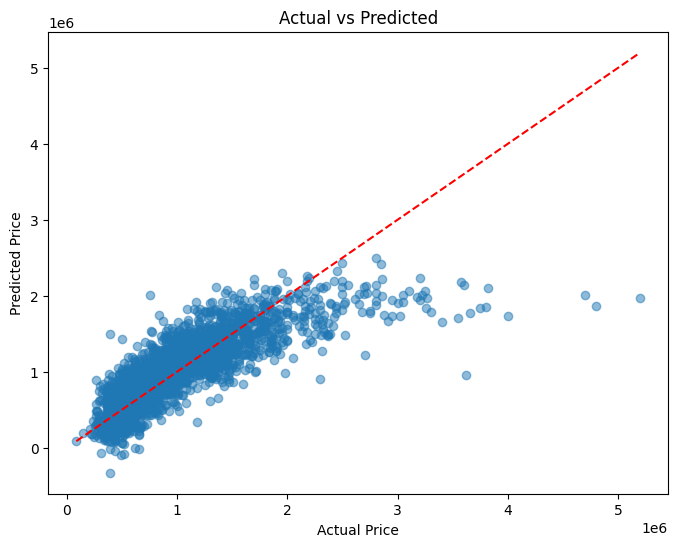

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()

พล็อคกราฟออกมาดูปรากฏว่าข้อมูลกระจุกตัวอยู่ในช่วง 0-3 แสดงว่าราคาบ้านส่วนใหญ่จะอยู่ในโซนราคาประมาณนี้

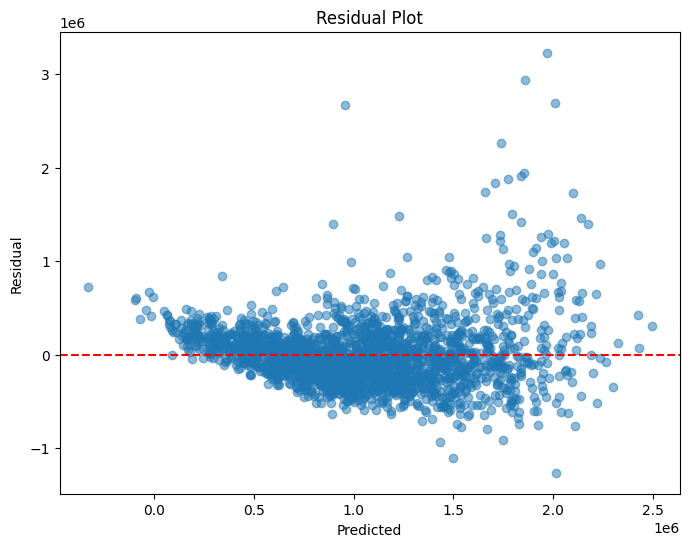

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Predicted')
plt.ylabel('Residual')

plt.title('Residual Plot')

plt.show()

เป็นการพล็อตกราฟเพื่อเช็คข้อมูล การกระจายตัว ถ้าข้อมูลกระจายตัวเป็นใบพัดมีโอกาสเกิด outlier การกระจายตัวที่ผิดปกติ

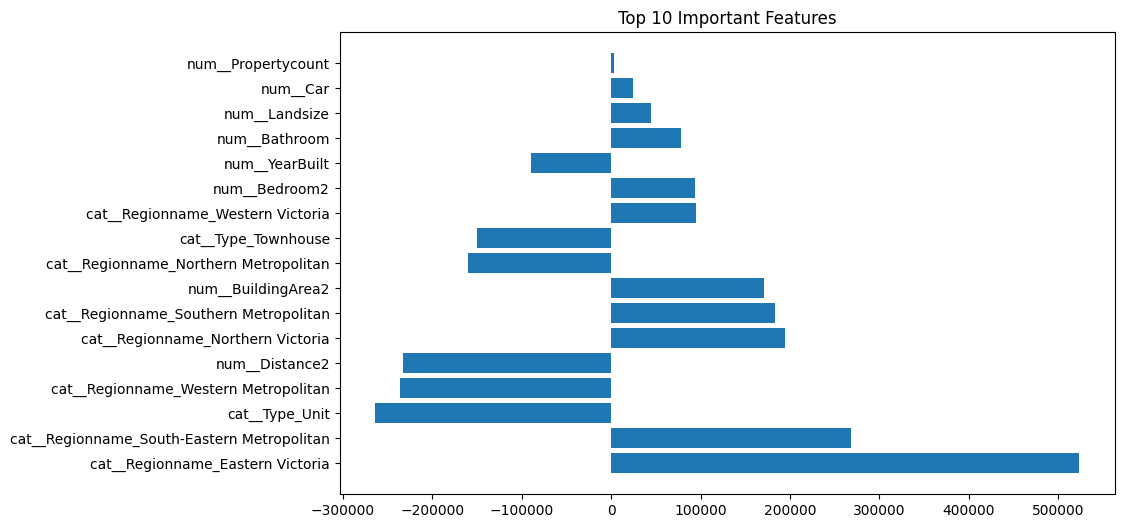

In [ ]:
feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = model.named_steps[
    'regressor'
].coef_

coef_df = pd.DataFrame({
    'Feature':feature_names,
    'Coefficient':coefficients
})

coef_df = coef_df.reindex(
    coef_df['Coefficient']
    .abs()
    .sort_values(ascending=False)
    .index
)

coef_df.head(20)

top10 = coef_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top10['Feature'],
    top10['Coefficient']
)

plt.title('Top 10 Important Features')
plt.show()

ในส่วนนี้จะเป็นคำตอบจากการทำนายของโมเดล ปรากฏว่าบ้านที่อยู่ในโซน Eastern Victoria จะมีแนวโน้มราคาเพิ่มขึ้นกว่าที่อื่นประมาณ500,000บาท

ส่วนระยะทาง Distanceก็มีผลกับราคายื่งอยู่ห่างจากตัวเมืองมากเท่าไหร่จะราคา
ถูกลงประมาณ200,000กว่าบาท